In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import scipy.io as io
import argparse

import src.models.models as models
import src.training.self_supervision as ssl
import src.utils.utils as utils
import src.utils.extractor as extractor

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
else:
    print(f"{torch.cuda.is_available()}")
    dev = "cpu"

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may hav

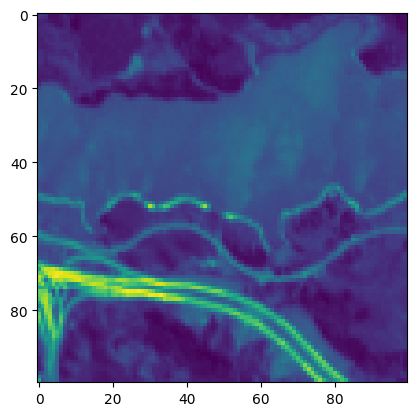

In [2]:
dataset = "jasper"
data = io.loadmat(f"datasets/{dataset}.mat")
Y = torch.tensor(data["Y"])
Y = Y.to(torch.float32)
E = torch.tensor(data["E"])
B, c, N = E.shape[0], E.shape[1], Y.shape[1]

Y = Y.reshape(Y.shape[0], int(Y.shape[1]**0.5), int(Y.shape[1]**0.5))
H, W = Y.shape[1], Y.shape[2]

patch_size = 100

plt.imshow(Y.cpu()[10,:,:])

In [3]:
# dataset_full = utils.HSI_dataset(dataset=dataset)
# dataset_patched = utils.HSI_dataset(dataset=dataset, patch_size=patch_size)
# full_loader = DataLoader(dataset_full)
# patched_loader = DataLoader(dataset_patched)

full_loader, _, _ = utils.create_dataloader(dataset, dev)
patched_loader, test_loader, B, _ = utils.create_dataloader(dataset, dev, 0.7, patch_size)

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/torch/utils/data/dataset.py:469: UserWarning: Length of split at index 1 is 0. This might result in an empty dataset.
  warnings.warn(


## Models

### MLP AE ✅

In [43]:
mlpae = models.MLP_AE(B=B, c=c)
sum(p.numel() for p in mlpae.parameters() if p.requires_grad)

160044

### CNNAE + linear mapping ✅

In [44]:
cnnlinear = models.CNNAE_linear(B=B, c=c, patch_size=patch_size)
sum(p.numel() for p in cnnlinear.parameters() if p.requires_grad)

150642

### CNNAEU ✅

In [4]:
Y_init, e_gt, a_gt = next(iter(full_loader))[0][0], next(iter(full_loader))[1][0], next(iter(full_loader))[2][0]

In [5]:
cnnaeu = models.CNNAEU(B=B, c =c)
cnnaeu = models.init_decoder_weights(cnnaeu, Y_init, c, 11)
sum(p.numel() for p in cnnaeu.parameters() if p.requires_grad)

181664

### Transformer AE ✅
*Accepts higher patch sizes than CNN linear*

In [ ]:
Y_trans = Y[:,:patch_size,:patch_size]
transformer_patched = models.Transformer_AE(B=B, c=c, im_size=Y_trans.shape[1], dim=200)
transformer_patched = models.init_decoder_weights(transformer_patched, Y_init, c)
sum(p.numel() for p in transformer_patched.parameters() if p.requires_grad)

14125646

### NALMU ✅

In [ ]:
nalmu_full = models.NALMU(B=B, c=c, N=N)
nalmu_patched = models.NALMU(B=B, c=c, N=patch_size**2)
sum(p.numel() for p in nalmu_full.parameters() if p.requires_grad)

5664660

### RALMU ✅

In [ ]:
ralmu_full = models.RALMU(B=B, c=c, im_size=H)
ralmu_patched = models.RALMU(B=B, c=c, im_size=patch_size)
sum(p.numel() for p in ralmu_full.parameters() if p.requires_grad)

2274170

## SSL methods

In [6]:
model = cnnaeu
epochs = 100
lr = 1e-2

### Reconstruction error

Saved permanent model CNNAEU_RE_lr_0.01_epoch_10.pt
Saved permanent model CNNAEU_RE_lr_0.01_epoch_20.pt
Saved permanent model CNNAEU_RE_lr_0.01_epoch_30.pt
Saved permanent model CNNAEU_RE_lr_0.01_epoch_40.pt
Saved permanent model CNNAEU_RE_lr_0.01_epoch_50.pt
Saved permanent model CNNAEU_RE_lr_0.01_epoch_60.pt
Saved permanent model CNNAEU_RE_lr_0.01_epoch_70.pt
Saved permanent model CNNAEU_RE_lr_0.01_epoch_80.pt
Saved permanent model CNNAEU_RE_lr_0.01_epoch_90.pt
torch.Size([198, 4]) torch.Size([1, 4, 10000])


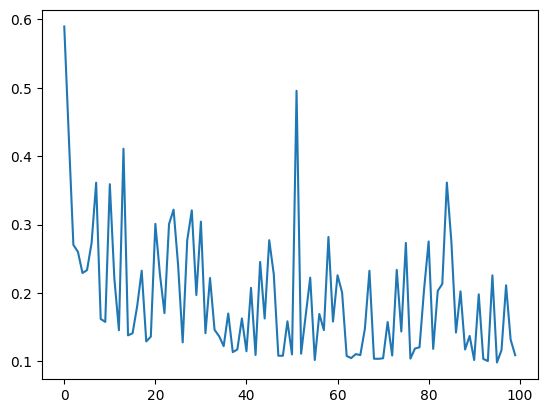

In [96]:
re_trainer = ssl.ReconstructionError(model, epochs=epochs, lr=lr)
e_hat_re, a_hat_re, train_losses_re = re_trainer.train(full_loader)
print(e_hat_re.shape, a_hat_re.shape)

plt.plot(train_losses_re)

### DIP

In [ ]:
# dip_trainer = ssl.DIP(model, epochs=epochs, lr=lr)
# e_hat_dip, a_hat_dip, train_losses_dip = dip_trainer.train(full_loader)
# print(e_hat_dip.shape, a_hat_dip.shape)

# plt.plot(train_losses_dip)

### Two stages net

In [ ]:
# two_s_trainer = ssl.TwoStagesNet(model, B, epochs=epochs, lr=lr)
# e_hat_twos, a_hat_twos, train_losses_twos = two_s_trainer.train(full_loader)
# print(e_hat_twos.shape, a_hat_twos.shape)

# plt.plot(train_losses_twos)

### Testing learned model:

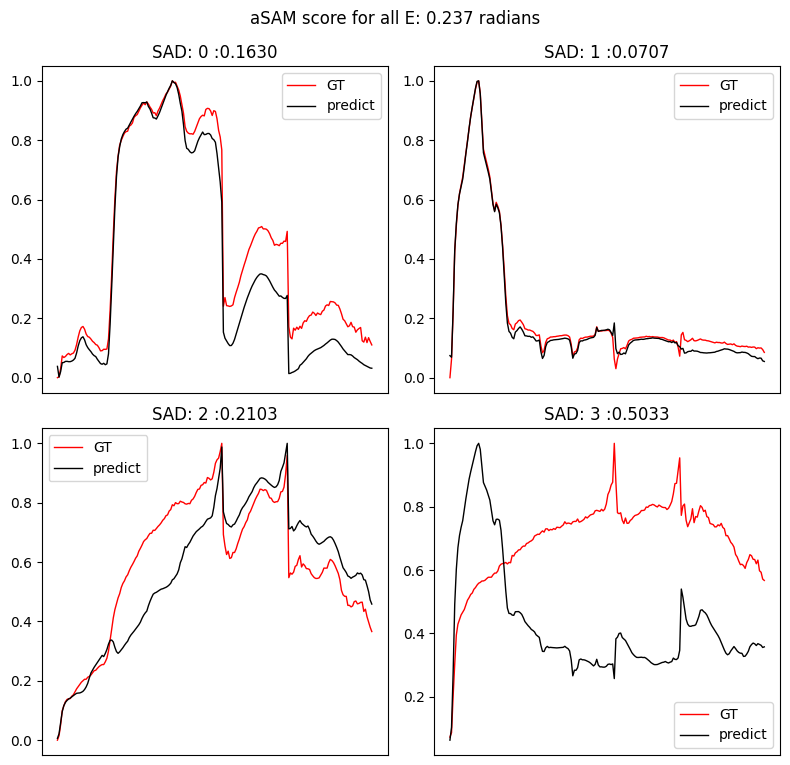

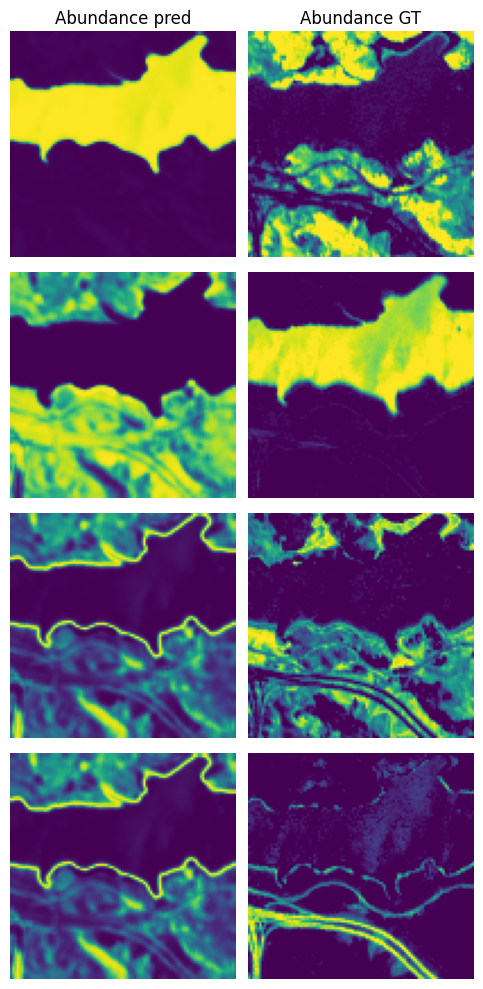

(array([0.18612073, 0.00313042, 0.11351153, 0.05606492, 0.08970691],
       dtype=float32),
 array([0.16298902, 0.07071948, 0.21032597, 0.50325894, 0.23682302]))

In [7]:
model.load_state_dict(torch.load("models/CNNAEU_RE_lr_0.01_epoch_90.pt")["model_state_dict"], strict=False)

# Y = torch.tensor(data["Y"])
# Y = Y.to(torch.float32)[:, :patch_size**2]
Y_init, e_gt, a_gt = next(iter(full_loader))[0][0], next(iter(full_loader))[1][0], next(iter(full_loader))[2][0]
Y = Y_init

e_hat, a_hat, y_hat = model.forward(Y)
e_hat = extractor.normalize_endmembers(e_hat)

if e_hat.dim() == 3:
    e_hat = e_hat.squeeze(0)

a_hat = a_hat.reshape(a_hat.shape[1], int(a_hat.shape[2]**0.5), int(a_hat.shape[2]**0.5))
a_gt = a_gt.reshape(a_gt.shape[0], int(a_gt.shape[1]**0.5), int(a_gt.shape[1]**0.5))

# e_hat = e_hat.T
# e_gt = e_gt.T

utils.compute_metrics_and_plot(e_hat, e_gt, a_hat, a_gt)
    
# model = cnnaeu
# re, sad = utils.test_model(model, full_loader)
# print(re, sad)

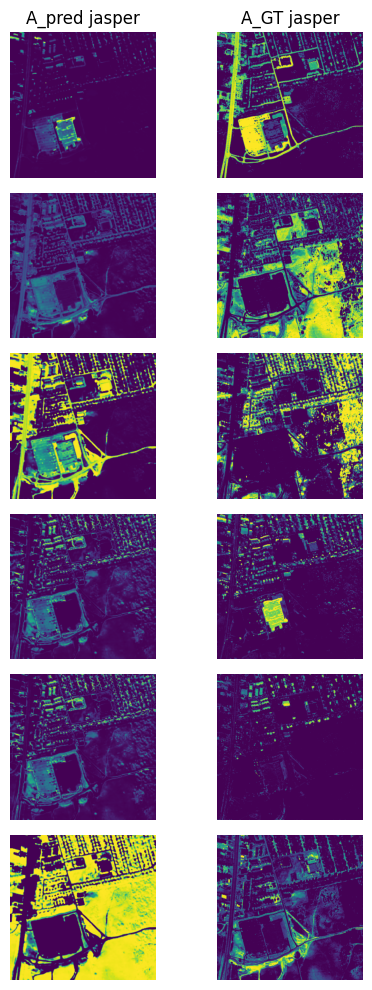

In [70]:
"""
Display extracted abundance matrix
"""
tensor, tensor_gt = a_hat, a_gt
fig, axes = plt.subplots(tensor.shape[0], 2, figsize=(5, 10))

axes[0, 0].set_title("A_pred jasper", fontsize=12)
axes[0, 1].set_title("A_GT jasper", fontsize=12)

# Plot tensor images
for i in range(tensor.shape[0]):
    axes[i, 0].imshow(tensor[i].detach().cpu())
    axes[i, 0].axis('off')

    axes[i, 1].imshow(tensor_gt[i].detach().cpu())
    axes[i, 1].axis('off')

# Adjust layout to reduce white space
plt.subplots_adjust(wspace=0.05, hspace=0.1)
plt.tight_layout()
plt.show()

In [45]:
import numpy as np

def numpy_SAD(y_true, y_pred):
    return np.arccos(np.dot(y_pred, y_true) / (np.linalg.norm(y_true) * np.linalg.norm(y_pred)))

def order_endmembers(endmembers, endmembersGT):
    num_endmembers = endmembers.shape[0]
    dict = {}
    SAD_ = []
    sad_mat = np.ones((num_endmembers, num_endmembers))
    for i in range(num_endmembers):
        endmembers[i, :] = endmembers[i, :] / endmembers[i, :].max()
        endmembersGT[i, :] = endmembersGT[i, :] / endmembersGT[i, :].max()
    for i in range(num_endmembers):
        for j in range(num_endmembers):
            sad_mat[i, j] = numpy_SAD(endmembers[i, :], endmembersGT[j, :])
    rows = 0
    while rows < num_endmembers:
        minimum = sad_mat.min()
        index_arr = np.where(sad_mat == minimum)
        if minimum == 100:
            break
        if len(index_arr) < 2:
            break
        index = (index_arr[0][0], index_arr[1][0])
        dict[index[1]] = index[0]  # keep Gt at first,
        SAD_.append(minimum)
        # dict[index[0]] = index[1]
        sad_mat[index[0], index[1]] = 100
        rows += 1
        sad_mat[index[0], :] = 100
        sad_mat[:, index[1]] = 100
    SAD_ = np.array(SAD_)
    Average_SAM = np.sum(SAD_)/ len(SAD_)
    return dict, SAD_, Average_SAM

def alter_MSE(y_true, y_pred):
    # y_true:[num_em,H,W]
    # y_pred:[num_em,H,W]

    num_em = y_true.shape[0]
    y_true = np.reshape(y_true , [num_em, -1])
    y_pred = np.reshape(y_pred , [num_em, -1])

    R = y_pred - y_true
    r = R*R
    mse = np.mean(r, axis=1)
    Average_mse = np.sum(mse) / len(mse)
    mse = np.insert(mse, num_em, Average_mse, axis=0)
    return mse

torch.Size([4, 198]) torch.Size([4, 198])
[0.05438308 0.30574155 0.04187233 0.33524406 0.18431026]


/tmp/ipykernel_152537/2300415383.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.arccos(np.dot(y_pred, y_true) / (np.linalg.norm(y_true) * np.linalg.norm(y_pred)))


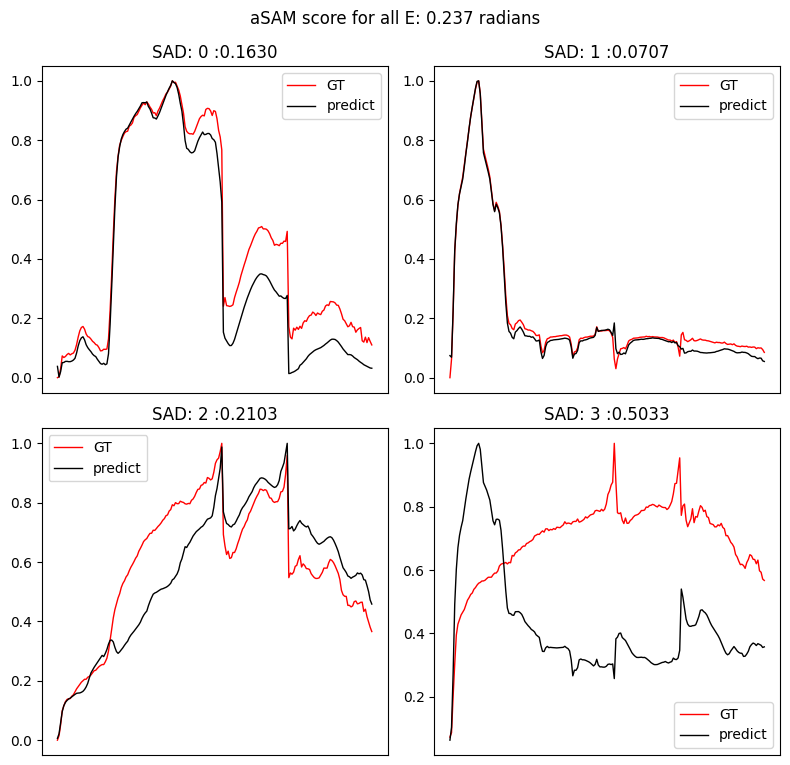

In [ ]:
print(e_hat.shape, e_gt.shape)

num_E = e_hat.shape[0]
n = num_E // 2
if num_E % 2 != 0: n = n + 1

dict, SAD_, Average_SAM = order_endmembers(e_hat.cpu().numpy(), e_gt.cpu().numpy())
SAD_ordered = []
endmember_ordered = []
abundance_ordered = []

fig = plt.figure(num=1, figsize=(8, 8))
plt.clf()
title = "aSAM score for all E: " + format(Average_SAM, '.3f') + " radians"
st = plt.suptitle(title)
for i in range(num_E):
    e_hat[i, :] = e_hat[i, :] / e_hat[i, :].max()
    e_gt[i, :] = e_gt[i, :] / e_gt[i, :].max()

for i in range(num_E):
    endmember_ordered.append(e_hat[dict[i]].cpu())
    abundance_ordered.append(a_hat[dict[i], :, :].detach().cpu())
endmember_ordered = np.array(endmember_ordered)
for i in range(num_E):
    z = numpy_SAD(endmember_ordered[i], e_gt[i, :].cpu())
    SAD_ordered.append(z)

for i in range(num_E):
    ax = plt.subplot(2, n, i + 1)
    plt.plot(e_gt[i, :].cpu(), 'r', linewidth=1.0, label='GT')
    plt.plot(endmember_ordered[i, :], 'k-', linewidth=1.0, label='predict')
    plt.legend()
    ax.set_title("SAD: " + str(i) + " :" + format(SAD_ordered[i], '.4f'))
    ax.get_xaxis().set_visible(False)
    
SAD_ordered.append(Average_SAM)
SAD_ordered = np.array(SAD_ordered)

abundance_ordered = np.array(abundance_ordered)

MSE = alter_MSE(a_gt.cpu().numpy(), abundance_ordered)
print(MSE)

plt.tight_layout()
st.set_y(0.95)
fig.subplots_adjust(top=0.88)
plt.draw()
plt.pause(0.001)

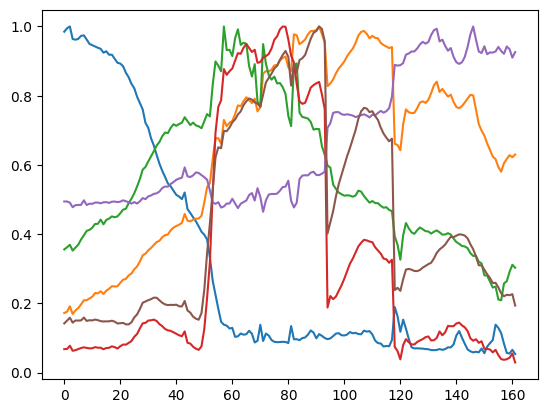

In [ ]:
"""
Display extracted endmembers
"""
for i in range(c):
    plt.plot(E_hat[:,i].cpu().detach())
plt.show()